# Introdução à Análise de Séries Temporais

**Objetivo:** Introduzir o conceito de séries temporais, como criá-las, visualizá-las e decompor seus componentes principais.

## O que são Séries Temporais?
São sequências de dados indexados no tempo, geralmente em intervalos regulares. Aplicadas em previsão de vendas, clima, mercado financeiro, etc. 

## Exemplos:
 - Preço de ações por dia.
 - Temperatura horária de uma cidade.
 - Vendas mensais de uma loja.

### **Criando uma Série Temporal**

Importando Bibliotecas

## Importando bibliotecas
 - `pandas` e `numpy`: manipulação de dados
 - `matplotlib`, `seaborn`: visualização
 - `statsmodels`: ferramentas estatísticas e decomposição
 - `prophet`: modelo de decomposição avançado (opcional)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import datetime, timedelta

Configurando saída dos gráficos

In [2]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6 

## Criando uma série anual

Criar uma série de 1980 a 2022 , que tenha distribuição normal de média 0 e desvio 1.

In [3]:
np.random.seed(102)
dados1 = np.random.normal(0,1,43) 
dados1

array([ 1.6680683 ,  0.92586182,  1.05799677, -0.92033901,  1.29974847,
        0.33118301, -0.50984497, -0.90309892, -0.13001637, -2.23820349,
        0.97316488, -0.02418481, -0.48492775, -1.10926436, -0.55897476,
        1.04238657, -1.71226271,  0.13611989, -0.46444399,  0.05097984,
        1.44789871,  0.59313848, -0.75561568, -0.62716553,  0.88403489,
        0.16271776, -2.50281287,  0.41079099,  0.72875041,  0.0291402 ,
       -0.29105246,  0.31429308,  0.99718968,  3.42856293, -0.57856735,
       -0.20416301, -1.86716866,  1.44343395,  0.40338004, -0.6907654 ,
        1.17228746, -1.5711284 ,  0.80199231])

In [4]:
type(dados1) 

numpy.ndarray

Transformar os dados em série temporal

In [5]:
serie = pd.Series(dados1)

In [6]:
type(serie)

pandas.core.series.Series

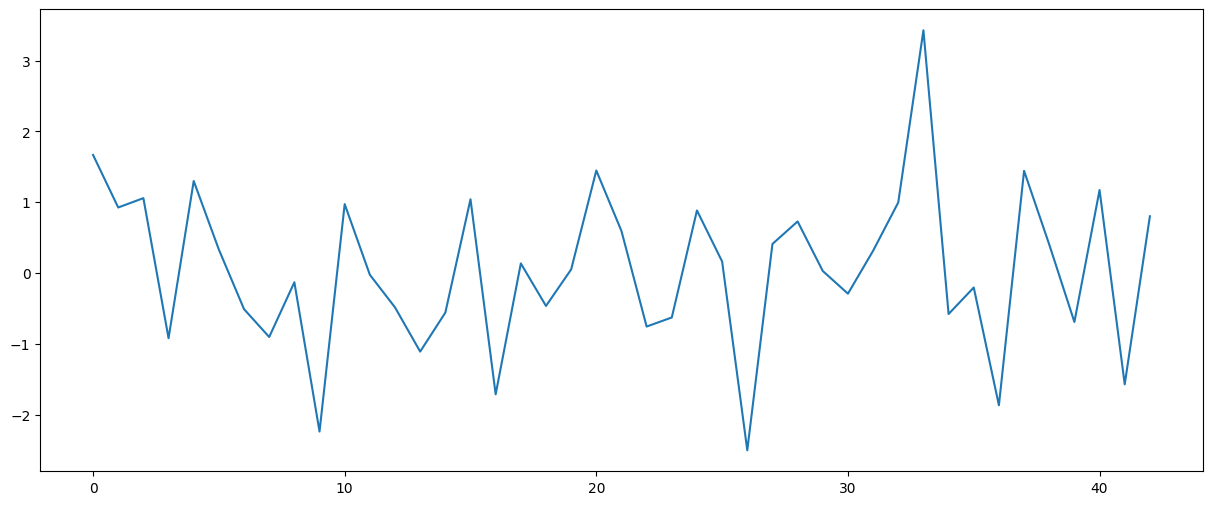

In [7]:
serie.plot()
plt.show()

Criando as datas - Ano

In [8]:
dados1 = pd.DataFrame(dados1) 
dados1

,0
0,1.668068
1,0.925862
2,1.057997
3,-0.920339
4,1.299748
5,0.331183
6,-0.509845
7,-0.903099
8,-0.130016
9,-2.238203


In [9]:
dados1.columns = ['valores'] 
dados1.head()

,valores
0,1.668068
1,0.925862
2,1.057997
3,-0.920339
4,1.299748


In [10]:
dados1.shape 

(43, 1)

Análise Descritiva

In [11]:
dados1.describe() 

,valores
count,43.000000
mean,0.050212
std,1.150257
min,-2.502813
25%,-0.602866
50%,0.050980
75%,0.904948
max,3.428563


Criando um range de datas que vai de 1980 até o tamanho dos dados1 = 43 , frequencia anual "Y"

In [12]:
indice = pd.date_range('1980', periods = len(dados1), freq = 'Y') 
indice

DatetimeIndex(['1980-12-31', '1981-12-31', '1982-12-31', '1983-12-31',
               '1984-12-31', '1985-12-31', '1986-12-31', '1987-12-31',
               '1988-12-31', '1989-12-31', '1990-12-31', '1991-12-31',
               '1992-12-31', '1993-12-31', '1994-12-31', '1995-12-31',
               '1996-12-31', '1997-12-31', '1998-12-31', '1999-12-31',
               '2000-12-31', '2001-12-31', '2002-12-31', '2003-12-31',
               '2004-12-31', '2005-12-31', '2006-12-31', '2007-12-31',
               '2008-12-31', '2009-12-31', '2010-12-31', '2011-12-31',
               '2012-12-31', '2013-12-31', '2014-12-31', '2015-12-31',
               '2016-12-31', '2017-12-31', '2018-12-31', '2019-12-31',
               '2020-12-31', '2021-12-31', '2022-12-31'],
              dtype='datetime64[ns]', freq='A-DEC')

Montando novamente a serie, agora com os valores de dados1 e criando o index como indice(data)

In [13]:
serie1 = pd.Series(dados1['valores'].values, index = indice) 

In [15]:
type(serie1)

pandas.core.series.Series

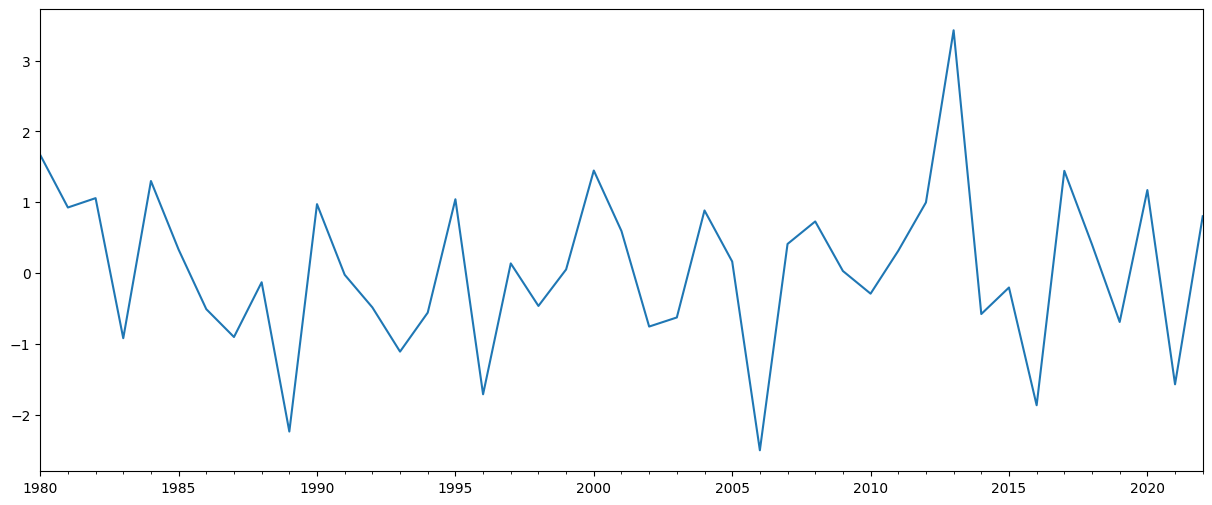

In [16]:
serie1.plot()
plt.show()

## Criando uma série mensal

In [17]:
np.random.seed(6)
dados2 = np.random.normal(0,1,96)
dados2

array([-0.31178367,  0.72900392,  0.21782079, -0.8990918 , -2.48678065,
        0.91325152,  1.12706373, -1.51409323,  1.63929108, -0.4298936 ,
        2.63128056,  0.60182225, -0.33588161,  1.23773784,  0.11112817,
        0.12915125,  0.07612761, -0.15512816,  0.63422534,  0.810655  ,
        0.35480861,  1.81259031, -1.3564758 , -0.46363197,  0.82465384,
       -1.17643148,  1.56448966,  0.71270509, -0.1810066 ,  0.53419953,
       -0.58661296, -1.48185327,  0.85724762,  0.94309899,  0.11444143,
       -0.02195668, -2.12714455, -0.83440747, -0.46550831,  0.23371059,
        1.38503523, -0.51962709, -0.78015214,  0.95560959, -0.12673638,
       -1.36861282,  1.21848065, -0.85750144, -0.56147088, -1.0335199 ,
        0.35877096,  1.07368134, -0.37550472,  0.39636757, -0.47144628,
        2.33660781,  1.50278553, -0.59545972,  0.52834106,  0.9398248 ,
        0.42628539, -0.75815703, -0.16236698,  0.72680996,  0.44408297,
       -0.85682264,  0.44692842, -1.01464799, -2.1323234 ,  0.17

In [18]:
type(dados2)

numpy.ndarray

Criando o data frame com a variavel

In [19]:
dados2 = pd.DataFrame(dados2)
dados2

,0
0,-0.311784
1,0.729004
2,0.217821
3,-0.899092
4,-2.486781
...,...
91,-0.591876
92,-0.477487
93,0.112530
94,1.904742


In [20]:
dados2.columns = ['valores']
dados2.head()

,valores
0,-0.311784
1,0.729004
2,0.217821
3,-0.899092
4,-2.486781


Análise descritiva

In [21]:
dados2.describe()

,valores
count,96.000000
mean,0.099655
std,1.007290
min,-2.486781
25%,-0.567756
50%,0.151402
75%,0.797581
max,2.631281


In [22]:
dados2.shape

(96, 1)

In [23]:
data = np.array('2015-01', dtype = np.datetime64())
data

array('2015-01', dtype='datetime64[M]')

In [24]:
data = data + np.arange(96)
data

array(['2015-01', '2015-02', '2015-03', '2015-04', '2015-05', '2015-06',
       '2015-07', '2015-08', '2015-09', '2015-10', '2015-11', '2015-12',
       '2016-01', '2016-02', '2016-03', '2016-04', '2016-05', '2016-06',
       '2016-07', '2016-08', '2016-09', '2016-10', '2016-11', '2016-12',
       '2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06',
       '2017-07', '2017-08', '2017-09', '2017-10', '2017-11', '2017-12',
       '2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06',
       '2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12',
       '2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06',
       '2019-07', '2019-08', '2019-09', '2019-10', '2019-11', '2019-12',
       '2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06',
       '2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12',
       '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06',
       '2021-07', '2021-08', '2021-09', '2021-10', 

In [25]:
data = pd.DataFrame(data) 
data

,0
0,2015-01-01
1,2015-02-01
2,2015-03-01
3,2015-04-01
4,2015-05-01
...,...
91,2022-08-01
92,2022-09-01
93,2022-10-01
94,2022-11-01


In [26]:
data.columns = ['data']
data.head()

,data
0,2015-01-01
1,2015-02-01
2,2015-03-01
3,2015-04-01
4,2015-05-01


In [27]:
data.shape

(96, 1)

In [28]:
serie2 =  pd.Series(dados2['valores'].values, index = data['data'])

In [29]:
type(serie2)

pandas.core.series.Series

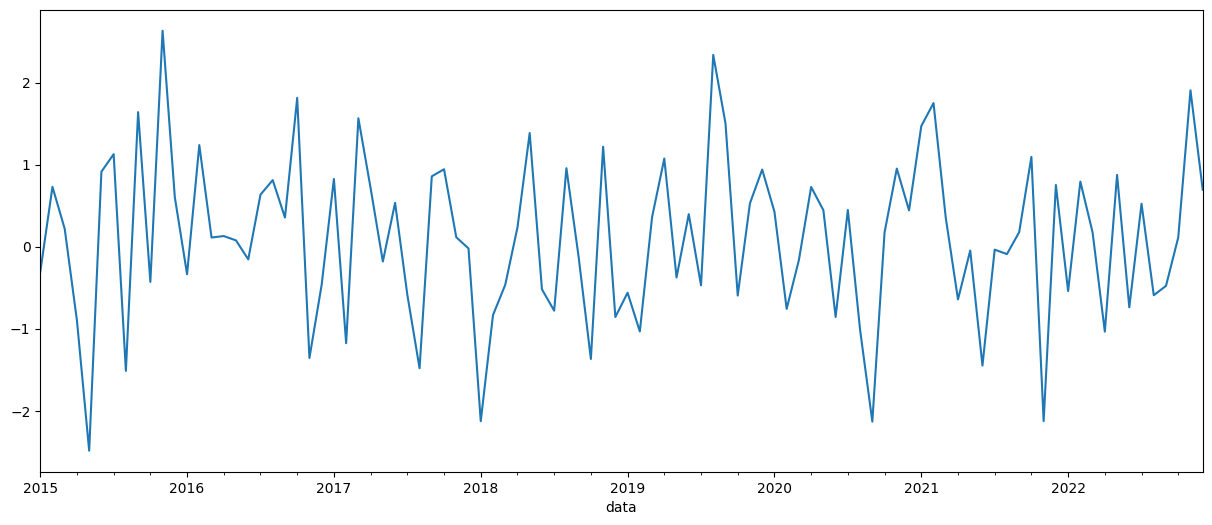

In [30]:
serie2.plot()
plt.show()

## Criando uma Série diária


In [31]:
np.random.seed(12)
dados3 = np.random.normal(1,2,731)
dados3

array([ 1.94597166, -0.36285176,  1.48487899, -2.40147127,  2.50628567,
       -2.06944268,  1.01025416,  0.75954466, -0.61396376,  6.74363879,
       -0.19564584,  1.94491399,  3.19191224, -1.4303376 ,  3.68471274,
        0.75570042,  3.02503095, -0.82773829, -1.05906041,  3.4195929 ,
        2.00374461,  1.27769235,  2.28152223,  2.05466533, -1.30872047,
       -3.42666696, -2.36351302, -2.5761885 , -3.43706989, -0.29486156,
       -0.05680864,  0.92158165,  1.4299519 ,  0.23128239,  0.49219184,
        1.14650415, -0.99440767, -0.42771258,  1.07083269, -0.35589073,
       -0.14376212,  0.78827537,  3.67166268,  1.63733058,  0.3248095 ,
       -0.17053656,  0.77016012,  5.48363559, -5.29483304,  2.07027179,
        1.46498088,  2.7352239 , -1.29642543,  5.22868848,  3.00188552,
        0.89717001,  1.3195754 , -0.43252717,  1.10104565,  0.71332517,
        2.88715078,  1.71528845,  0.83310159,  2.35561221,  2.11212075,
        1.44543892, -2.05797096,  3.05842235, -1.33251752, -1.01

In [32]:
type(dados3)

numpy.ndarray

In [33]:
dados3 = pd.DataFrame(dados3)
dados3

,0
0,1.945972
1,-0.362852
2,1.484879
3,-2.401471
4,2.506286
...,...
726,3.962740
727,-1.596531
728,-2.203829
729,2.479531


In [34]:
dados3.columns = ['valores']
dados3.head()

,valores
0,1.945972
1,-0.362852
2,1.484879
3,-2.401471
4,2.506286


In [35]:
dados3.describe()

,valores
count,731.000000
mean,0.932968
std,2.021317
min,-6.421359
25%,-0.467932
50%,1.046546
75%,2.333579
max,7.333114


In [36]:
dados3.shape

(731, 1)

In [37]:
indice3 = pd.date_range('2019 Jan 1', periods = len(dados3), freq = 'D')
indice3

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-01-05', '2019-01-06', '2019-01-07', '2019-01-08',
               '2019-01-09', '2019-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[ns]', length=731, freq='D')

In [38]:
serie3 = pd.Series(dados3['valores'].values, index = indice3)

In [39]:
type(serie3)

pandas.core.series.Series

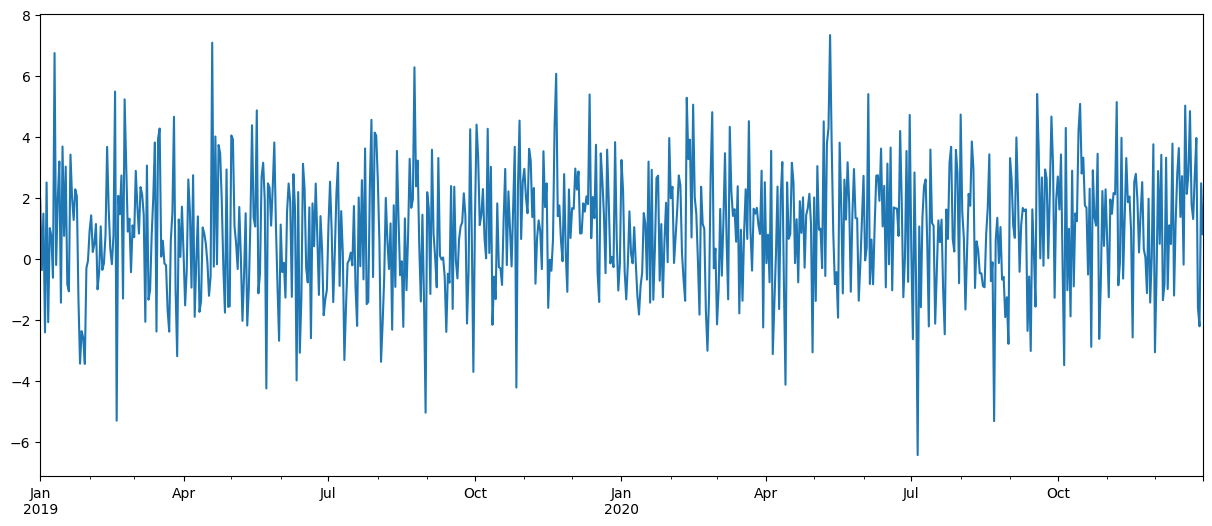

In [40]:
serie3.plot()
plt.show()

## Criando uma Série Trimestral

In [41]:
np.random.seed(20)
dados4 = np.random.normal(0,1,164)
dados4

array([ 8.83893113e-01,  1.95865022e-01,  3.57536516e-01, -2.34326191e+00,
       -1.08483259e+00,  5.59696289e-01,  9.39469350e-01, -9.78481042e-01,
        5.03096840e-01,  4.06414469e-01,  3.23461010e-01, -4.93410882e-01,
       -7.92016791e-01, -8.42367934e-01, -1.27950266e+00,  2.45715170e-01,
       -4.41948007e-02,  1.56763255e+00,  1.05110868e+00,  4.06368426e-01,
       -1.68646101e-01, -3.18970279e+00,  1.12013226e+00,  1.33277821e+00,
       -2.43338766e-01, -1.30030711e-01, -1.09017371e-01,  1.55618644e+00,
        1.28778353e-01, -2.06694872e+00, -8.85493155e-01, -1.10457948e+00,
        9.32866347e-01,  2.05983800e+00, -9.34937958e-01, -1.61299022e+00,
        5.27069718e-01, -1.55110074e+00,  3.29613339e-01, -1.13652654e+00,
       -3.38490605e-01,  3.20970784e-01, -6.02308018e-01,  1.54472836e+00,
        6.47034084e-01,  5.93217213e-01,  4.38024497e-01,  1.35778902e+00,
        1.20451128e+00,  1.35179619e+00,  4.93437236e-01, -2.70436525e+00,
       -5.55185797e-01,  

In [42]:
dados4 = pd.DataFrame(dados4)
dados4

,0
0,0.883893
1,0.195865
2,0.357537
3,-2.343262
4,-1.084833
...,...
159,0.840389
160,0.724127
161,-0.180159
162,0.152579


In [43]:
dados4.columns = ['valores']
dados4.head()

,valores
0,0.883893
1,0.195865
2,0.357537
3,-2.343262
4,-1.084833


In [44]:
dados4.describe()

,valores
count,164.000000
mean,0.019060
std,1.051344
min,-3.189703
25%,-0.801186
50%,0.148101
75%,0.761434
max,2.094665


In [45]:
dados4.shape

(164, 1)

In [46]:
indice4 = pd.date_range('1980-01', periods = len(dados4), freq = '3M')
indice4

DatetimeIndex(['1980-01-31', '1980-04-30', '1980-07-31', '1980-10-31',
               '1981-01-31', '1981-04-30', '1981-07-31', '1981-10-31',
               '1982-01-31', '1982-04-30',
               ...
               '2018-07-31', '2018-10-31', '2019-01-31', '2019-04-30',
               '2019-07-31', '2019-10-31', '2020-01-31', '2020-04-30',
               '2020-07-31', '2020-10-31'],
              dtype='datetime64[ns]', length=164, freq='3M')

In [47]:
serie4 = pd.Series(dados4['valores'].values, index = indice4)

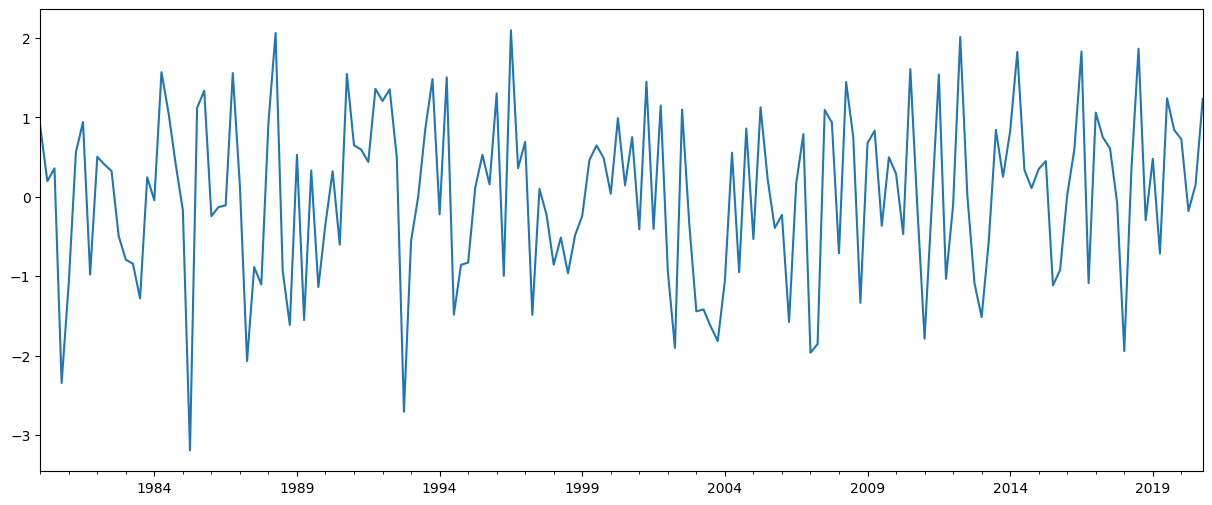

In [48]:
serie4.plot()
plt.show()

## Criando uma Série Temporal artificial
#### Vamos gerar dados simulados com componentes de tendência, sazonalidade e ruído.

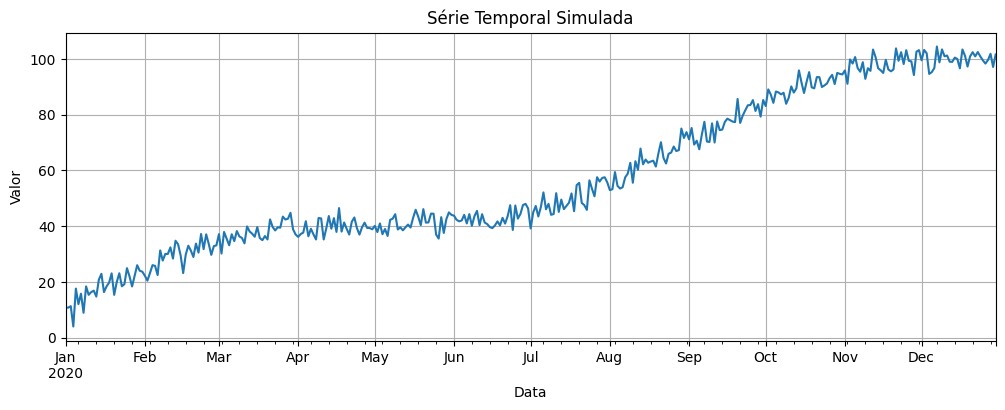

In [49]:
dates = pd.date_range(start="2020-01-01", periods=365, freq="D")
tendencia = np.linspace(10, 100, 365)
sazonalidade = 10 * np.sin(np.linspace(0, 3 * np.pi, 365))
ruido = np.random.normal(0, 3, 365)
data = tendencia + sazonalidade + ruido

serie = pd.Series(data, index=dates)
serie.plot(figsize=(12, 4), title="Série Temporal Simulada")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

## Componentes das Séries Temporais

 Uma série temporal pode ser decomposta em:
 - **Tendência:** direção de longo prazo
 - **Sazonalidade:** repetição periódica de padrões
 - **Ruído:** variação aleatória


#### Decomposição com `seasonal_decompose` (modelo aditivo)

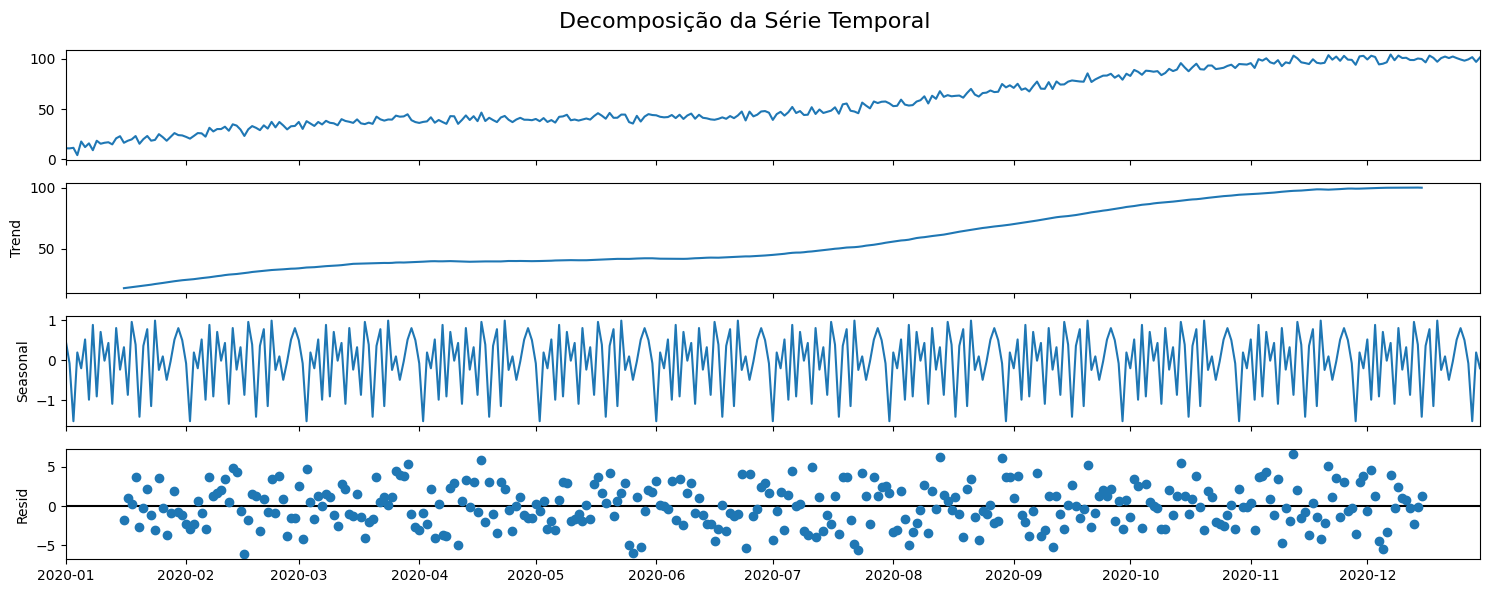

In [50]:
decomposicao = seasonal_decompose(serie, model="additive", period=30)
decomposicao.plot()
plt.suptitle("Decomposição da Série Temporal", fontsize=16)
plt.tight_layout()
plt.show()

## Decomposição de Séries Temporais 

Carregando a série temporal airpassengers

In [51]:
df = sns.load_dataset("flights")
df.head

<bound method NDFrame.head of      year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]>

Convertendo a coluna de data para o formato correto

In [52]:
df['date'] = df['year'].astype(str) + '-' + df['month'].astype(str)
df['date'] = pd.to_datetime(df['date'])

C:\Users\anail\AppData\Local\Temp\ipykernel_19324\2699355448.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


Criando um gráfico de Séries Temporais 

C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\anail\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


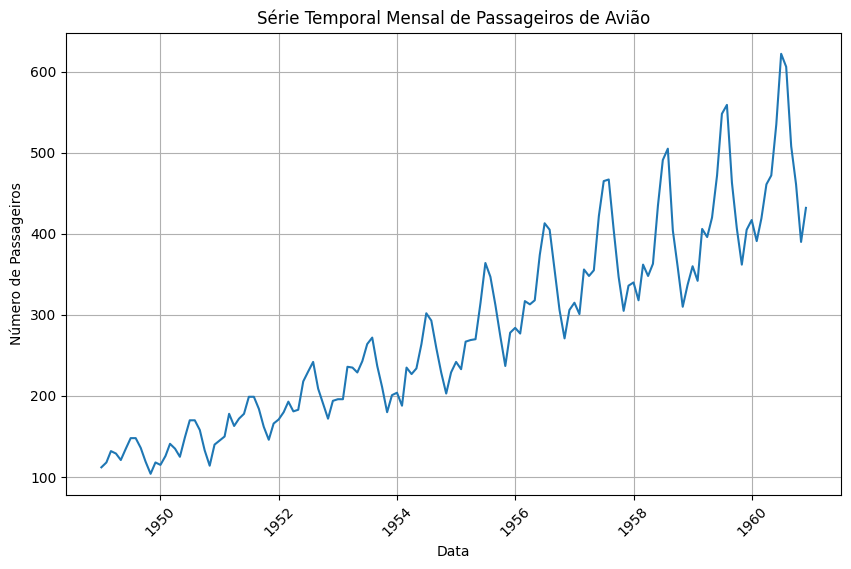

In [53]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="date", y="passengers", data=df)
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.title('Série Temporal Mensal de Passageiros de Avião')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Definindo a coluna de data como índice

In [54]:
df.set_index('date', inplace=True)

Realizando a decomposição aditiva

In [55]:
result_additive = seasonal_decompose(df['passengers'], model='additive')

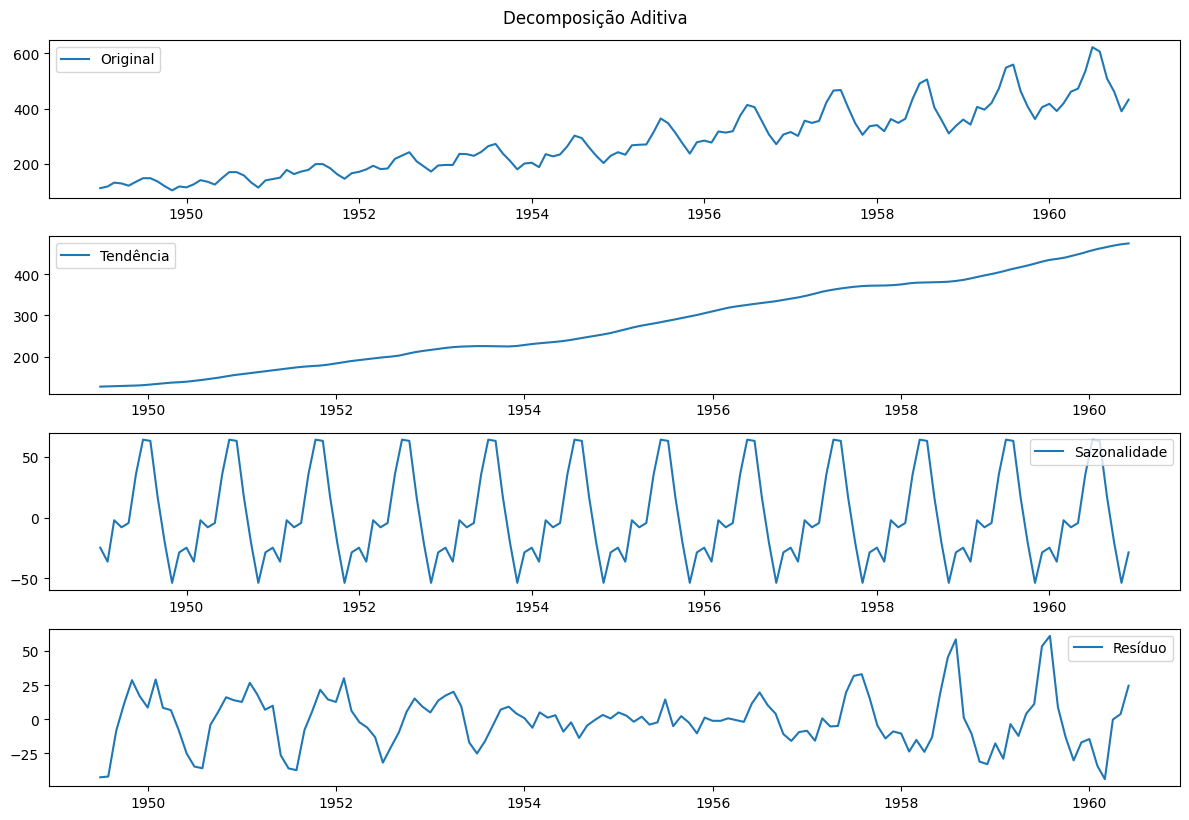

In [56]:
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(df['passengers'], label='Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result_additive.trend, label='Tendência')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result_additive.seasonal, label='Sazonalidade')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result_additive.resid, label='Resíduo')
plt.legend()

plt.tight_layout()
plt.suptitle('Decomposição Aditiva', y=1.02)
plt.show()

Realizando a decomposição multiplicativa

In [58]:
result_multiplicative = seasonal_decompose(df['passengers'], model='multiplicative')

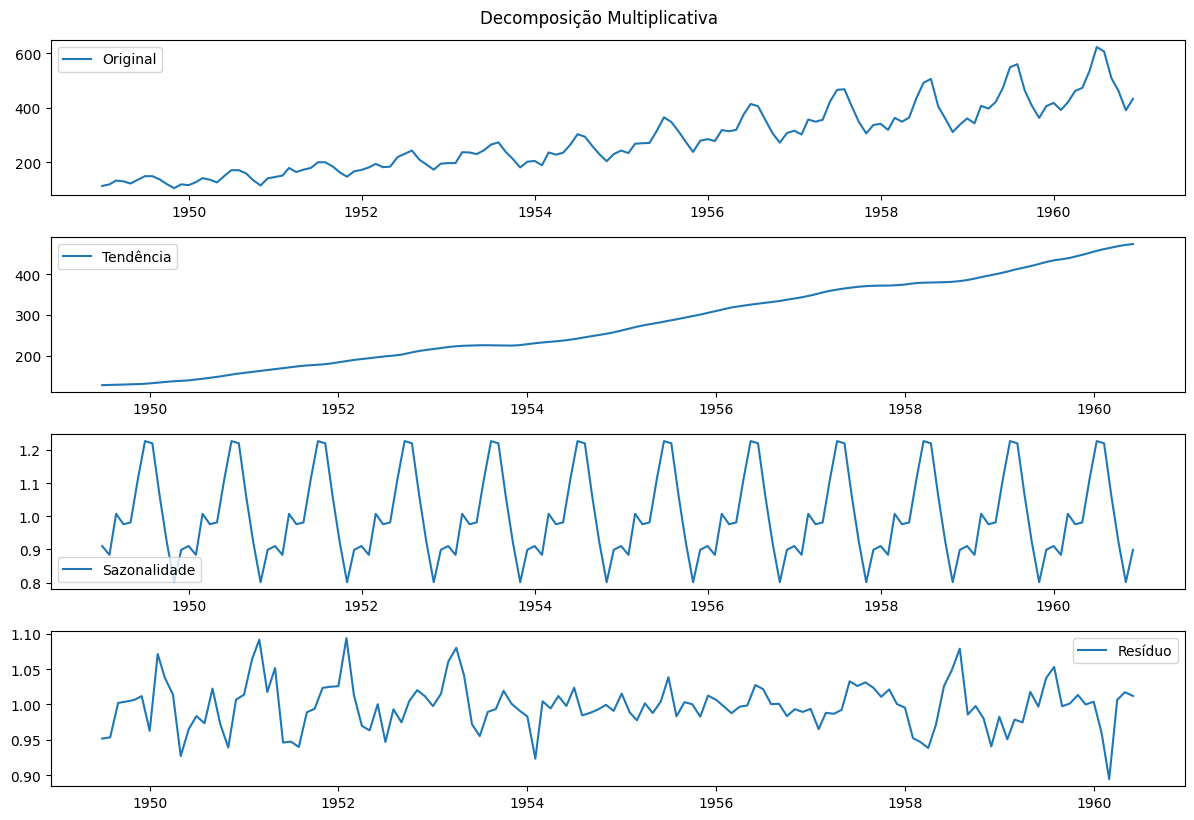

In [59]:
# Plotando os resultados da decomposição multiplicativa
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(df['passengers'], label='Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result_multiplicative.trend, label='Tendência')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result_multiplicative.seasonal, label='Sazonalidade')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result_multiplicative.resid, label='Resíduo')
plt.legend()

plt.tight_layout()
plt.suptitle('Decomposição Multiplicativa', y=1.02)
plt.show()